In [13]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
base = "../data/audio"

durations = {"english": [], "bangla": []}
sample_rates = {"english": [], "bangla": []}

for lang in ["english", "bangla"]:
    lang_dir = os.path.join(base, lang)

    for f in os.listdir(lang_dir):
        path = os.path.join(lang_dir, f)
        y, sr = librosa.load(path, sr=None, mono=False)
        durations[lang].append(len(y) / sr)
        sample_rates[lang].append(sr)

C:\Users\Ahad\AppData\Local\Temp\ipykernel_23084\861927286.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None, mono=False)
c:\Users\Ahad\anaconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
C:\Users\Ahad\AppData\Local\Temp\ipykernel_23084\861927286.py:11: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None, mono=False)
c:\Users\Ahad\anaconda3\Lib\site-packages\librosa\core\audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


In [3]:
print("Durations (seconds):")
for lang in durations:
    print(
        lang,
        f"min={min(durations[lang]):.2f}",
        f"max={max(durations[lang]):.2f}",
        f"mean={np.mean(durations[lang]):.2f}"
    )

Durations (seconds):
english min=0.00 max=236.64 mean=4.15
bangla min=0.00 max=281.05 mean=2.81


In [4]:
print("\nSample rates:")
for lang in sample_rates:
    print(lang, set(sample_rates[lang]))


Sample rates:
english {11025, 22050, 44100}
bangla {48000, 22050, 44100}


# Load MEL features

In [3]:
X = np.load("../data/features_mel/features.npy")
ids = np.load("../data/features_mel/ids.npy", allow_pickle=True)
langs = np.load("../data/features_mel/languages.npy", allow_pickle=True)

print(X.shape)

(200, 1, 128, 256)


# Global statistics check (sanity)

In [4]:
print("Mean:", X.mean())
print("Std:", X.std())
print("Min:", X.min())
print("Max:", X.max())

Mean: 4.7683717e-08
Std: 1.0
Min: -5.581852
Max: 3.9018972


# Visualize Mel-spectrograms

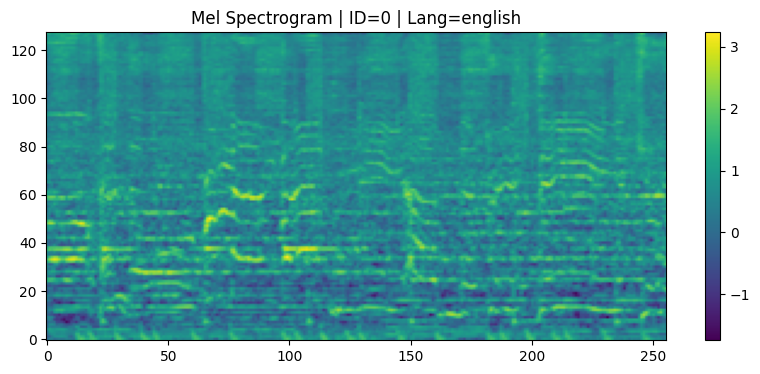

In [6]:
idx = 0
plt.figure(figsize=(10, 4))
plt.imshow(X[idx, 0], aspect="auto", origin="lower")
plt.colorbar()
plt.title(f"Mel Spectrogram | ID={ids[idx]} | Lang={langs[idx]}")
plt.show()

# English vs Bangla distribution

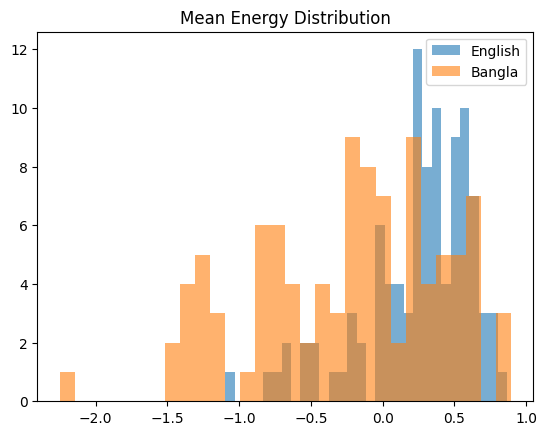

In [7]:
eng = X[langs == "english"]
bn  = X[langs == "bangla"]

plt.hist(eng.mean(axis=(1,2,3)), bins=30, alpha=0.6, label="English")
plt.hist(bn.mean(axis=(1,2,3)), bins=30, alpha=0.6, label="Bangla")
plt.legend()
plt.title("Mean Energy Distribution")
plt.show()

In [8]:
assert len(set([x.shape for x in X])) == 1
print("All feature shapes are consistent ✔")

All feature shapes are consistent ✔


# Load MFCC features

In [9]:
X_mfcc = np.load("../data/features_mfcc_flat/features.npy")
ids = np.load("../data/features_mfcc_flat/ids.npy", allow_pickle=True)
langs = np.load("../data/features_mfcc_flat/languages.npy", allow_pickle=True)

print(X_mfcc.shape)

(200, 10240)


In [10]:
print("Mean:", X_mfcc.mean())
print("Std:", X_mfcc.std())
print("Min:", X_mfcc.min())
print("Max:", X_mfcc.max())

Mean: 0.0
Std: 1.0
Min: -6.0426517
Max: 6.9246264


# MFCC coefficient behavior

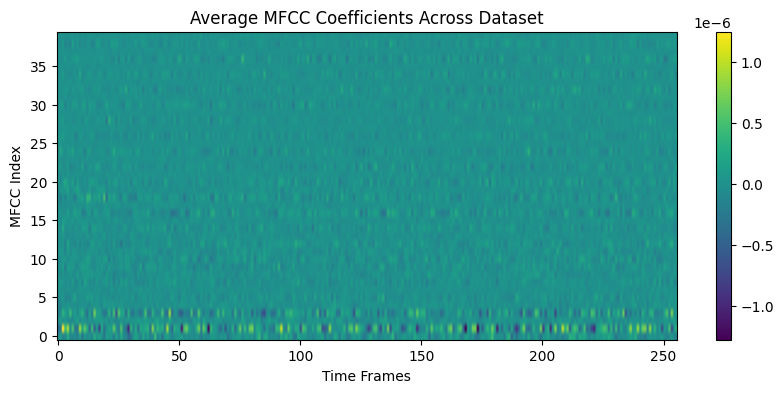

In [11]:
mfcc_mean = X_mfcc.mean(axis=0).reshape(40, 256)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.imshow(mfcc_mean, aspect="auto", origin="lower")
plt.colorbar()
plt.title("Average MFCC Coefficients Across Dataset")
plt.xlabel("Time Frames")
plt.ylabel("MFCC Index")
plt.show()

# English vs Bangla (MFCC space)

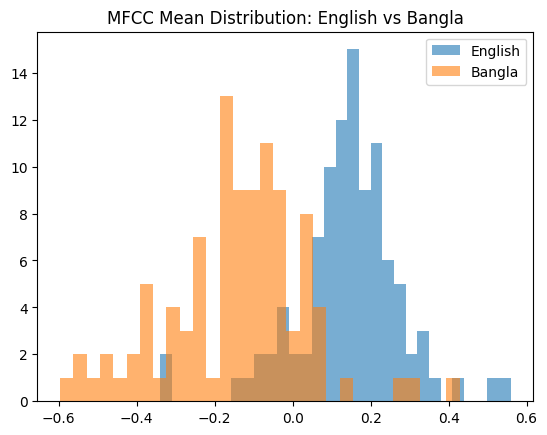

In [12]:
eng = X_mfcc[langs == "english"]
bn  = X_mfcc[langs == "bangla"]

plt.hist(eng.mean(axis=1), bins=30, alpha=0.6, label="English")
plt.hist(bn.mean(axis=1), bins=30, alpha=0.6, label="Bangla")
plt.legend()
plt.title("MFCC Mean Distribution: English vs Bangla")
plt.show()

# Dimensionality sanity

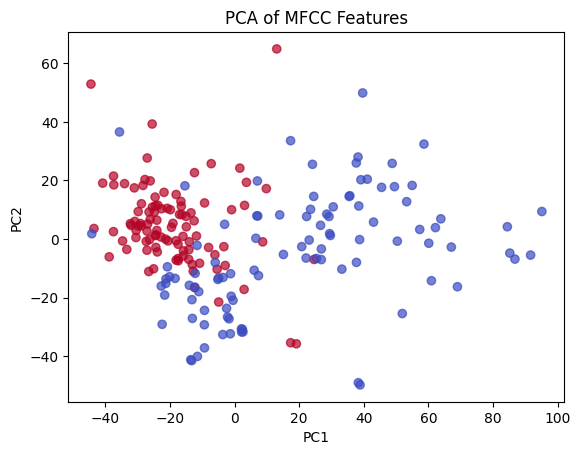

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_mfcc)

plt.scatter(X_pca[:,0], X_pca[:,1], c=(langs=="english"), cmap="coolwarm", alpha=0.7)
plt.title("PCA of MFCC Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# Shape consistency

In [15]:
assert X_mfcc.ndim == 2
assert X_mfcc.shape[1] == 40 * 256
print("MFCC feature shape is consistent ✓")

MFCC feature shape is consistent ✓
